# 07MIAR - Redes Neuronales y Deep Learning: Proyecto de programación "*Deep Vision in classification tasks*"


## Nombre y apellidos

* Rosa Chamorro Nieto
* Pablo Fenollera Faustino
* Iván Villanueva Villalón


## Enunciado

En esta actividad, el alumno debe **evaluar y comparar dos estrategias** para la **clasificación de imágenes** empleando el **dataset asignado**. Los alumnos deberá resolver el reto proponiendo una solución válida **basada en aprendizaje profundo**, más concretamente en redes neuronales convolucionales (**CNNs**). Será indispensable que la solución propuesta siga el **pipeline visto en clase** para resolver este tipo de tareas de inteligencia artificial:

1.   **Carga** del conjunto de datos
2.   **Inspección** del conjunto de datos
3.   **Acondicionamiento** del conjunto de datos
4.   Desarrollo de la **arquitectura** de red neuronal y **entrenamiento** de la solución
5.   **Monitorización** del proceso de **entrenamiento** para la toma de decisiones
6.   **Evaluación** del modelo predictivo y planteamiento de la siguiente prueba experimental

### Estrategia 1: Entrenar desde cero o *from scratch*

La primera estrategia a comparar será una **red neuronal profunda** que el **alumno debe diseñar, entrenar y optimizar**. Se debe **justificar empíricamente** las decisiones que llevaron a la selección de la **arquitectura e hiperparámetros final**. Se espera que el alumno utilice todas las **técnicas de regularización** mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (*weight regularization*, *dropout*, *batch normalization*, *data augmentation*, etc.).

### Estrategia 2: Red pre-entrenada

La segunda estrategia a comparar debe incluir la utilización de una **red preentrenada** con el dataset ImageNet, llevando a cabo tareas de ***transfer learning*** y ***fine-tuning*** para resolver la tarea de clasificación asignada. Deben **compararse al menos dos tipos de arquitecturas** (VGGs, ResNet50, Xception, InceptionV3, InceptionResNetV2, MobileNetV2, DenseNet, ResNet) y se debe **seleccionar la que mayor precisión proporcione** (información sobre las arquitecturas disponibles en https://keras.io/applications/). Se espera el uso de todas las **técnicas de regularización** mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (*weight regularization*, *dropout*, *batch normalization*, *data augmentation*, etc.).

## Normas a seguir

- Será **indispensable** realizar el **trabajo por parejas**. Dichas parejas de alumnxs se generarán **de manera automática** teniendo en cuenta el pais de residencia con el objetivo de facilitar el trabajo en equipo.  
- Se debe entregar un **ÚNICO FICHERO PDF POR ALUMNO** que incluya las instrucciones presentes en el Colab Noteboook y su **EJECUCIÓN!!!**. Debe aparecer todo el proceso llevado a cabo en cada estrategia (i.e. carga de datos, inspección de datos, acondicionamiento, proceso de entrenamiento y proceso de validación del modelo).
- **La memoria del trabajo** (el fichero PDF mencionado en el punto anterior) deberá **subirla cada integrante del grupo** (aunque se trate de un documento idéntico) a la actividad que se habilitará **en CampusVIU**.
- Se recomienda trabajar respecto a un directorio base (**BASE_FOLDER**) para facilitar el trabajo en equipo. En este notebook se incluye un ejemplo de cómo almacenar/cargar datos utilizando un directorio base.
- Las **redes propuestas** deben estar **entrenadas** (y **EVIDENCIAR este proceso en el documento PDF**). La entrega de una **red sin entrenar** supondrá **perdida de puntos**.
- Si se desea **evidenciar alguna métrica** del proceso de entrenamiento (precisión, pérdida, etc.), estas deben ser generadas.
- Todos los **gráficos** que se deseen mostrar deberán **generarse en el Colab Notebook** para que tras la conversión aparezcan en el documento PDF.

## Librerías

### Instalacion de librerias necesarias para ejecutar el programa

In [6]:
!pip install --upgrade --force-reinstall --no-deps kaggle
!pip install tqdm
!pip install zipfile
!pip install tensorflow
!pip install dotenv
!pip install slugify
!pip install --upgrade "kagglesdk>=0.1.28"

  Using cached kaggle-2.2.1-py3-none-any.whl.metadata (16 kB)
Using cached kaggle-2.2.1-py3-none-any.whl (132 kB)
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.2.1
    Uninstalling kaggle-2.2.1:
      Successfully uninstalled kaggle-2.2.1
ERROR: Could not find a version that satisfies the requirement zipfile (from versions: none)
ERROR: No matching distribution found for zipfile


### Imports

In [4]:
import zipfile
import os
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.applications import MobileNetV2, VGG16
from tensorflow.keras.optimizers import Adam

## Preprocesado
### 1.   **Carga** del conjunto de datos

In [7]:
# Descarga del dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Descompresion del dataset
with zipfile.ZipFile("chest-xray-pneumonia.zip", "r") as zip_ref:
    zip_ref.extractall("chest_xray")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:18<00:00, 137MB/s]



### 2.   **Inspección** del conjunto de datos

In [ ]:
# Ruta base donde están las carpetas train / val / test
base_path = os.path.join(os.getcwd(), "chest_xray", "chest_xray", "chest_xray")
print(base_path)

# Función para verificar si una imagen está dañada
def es_valida(ruta):
    try:
        Image.open(ruta).verify()
        return True
    except:
        return False


# Nombres de las clases (las obtenemos directamente de las carpetas)
class_names = sorted([
    clase for clase in os.listdir(os.path.join(base_path, "train")) 
    if not clase.startswith('.')
])
print("Clases detectadas en carpetas: ", class_names)

# Recorre train / val / test y elimina imágenes corruptas
for split in os.listdir(base_path):
    if not os.path.isfile(os.path.join(base_path, split)):
        for clase in class_names:
            carpeta = os.path.join(base_path, split, clase)
            for archivo in os.listdir(carpeta):
                ruta = os.path.join(carpeta, archivo)
                if not es_valida(ruta):
                    os.remove(ruta)
                    print("Imagen corrupta o archivo sobrante:", ruta)

# Carga del conjunto de entrenamiento
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_path, "train"),
    image_size=(224, 224),
    batch_size=16,
    shuffle=True,
    label_mode='binary',
)

# Carga del conjunto de validación
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_path, "val"),
    image_size=(224, 224),
    batch_size=16,
    label_mode='binary',
)

# Carga del conjunto de test
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_path, "test"),
    image_size=(224, 224),
    batch_size=16,
    label_mode='binary',
)

# Muestra las clases detectadas automáticamente
num_classes = len(train_ds.class_names)
class_names = train_ds.class_names
print("Clases del dataset: ", class_names)

# Conteo de imágenes por clase en cada partición
for split in os.listdir(base_path):
    if not os.path.isfile(os.path.join(base_path, split)):
        conteo = {
            clase: len(os.listdir(os.path.join(base_path, split, clase))) 
            for clase in os.listdir(os.path.join(base_path, split)) 
            if not os.path.isfile(os.path.join(base_path, clase))
        }
        print(f"Imágenes del conjunto de {split} por clase:", conteo)

/content/chest_xray/chest_xray/chest_xray
Clases detectadas en carpetas:  ['NORMAL', 'PNEUMONIA']
Imagen corrupta o archivo sobrante: /content/chest_xray/chest_xray/chest_xray/train/NORMAL/.DS_Store
Imagen corrupta o archivo sobrante: /content/chest_xray/chest_xray/chest_xray/train/PNEUMONIA/.DS_Store
Imagen corrupta o archivo sobrante: /content/chest_xray/chest_xray/chest_xray/val/NORMAL/.DS_Store
Imagen corrupta o archivo sobrante: /content/chest_xray/chest_xray/chest_xray/val/PNEUMONIA/.DS_Store
Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Clases del dataset:  ['NORMAL', 'PNEUMONIA']
Imágenes del conjunto de test por clase: {'PNEUMONIA': 390, 'NORMAL': 234}
Imágenes del conjunto de train por clase: {'PNEUMONIA': 3875, 'NORMAL': 1341}
Imágenes del conjunto de val por clase: {'PNEUMONIA': 8, 'NORMAL': 8}


### 3.   **Acondicionamiento** del conjunto de datos

In [9]:
# Normalización: escala los píxeles de [0,255] a [0,1]
normalization = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))
test_ds = test_ds.map(lambda x, y: (normalization(x), y))

# Data augmentation: aumenta variabilidad del dataset
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Aplica augmentation solo al conjunto de entrenamiento
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

# Optimización
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

## Estrategia 1: CNN from scratch

### Definición del modelo

#### Justificación de la arquitectura e hiperparámetros
##### 1. Evolución de la arquitectura

El modelo 1 es una CNN muy básica con dos bloques convolucionales seguidos por max pooling y una capa densa ligera. Esta arquitectura inicial sirve como referencia y permite comprobar si el problema puede resolverse con una red de baja complejidad.En el modelo 2 se  aumentar la profundidad se añade un tercer bloque convolucional y se incorporan normalización y dropout, lo que eleva la capacidad de modelado. Finalmente, en el modelo 3 se introduce global average pooling para reducir parámetros y mejorar la estabilidad, manteniendo tres bloques pero con una estructura más eficiente.

##### 2. Selección de Técnicas de Regularización

La selección de regularización combina técnicas que actúan en diferentes etapas del aprendizaje y ayudan a controlar el sobreajuste. El data augmentation aumenta la variedad del conjunto sin añadir nuevas imágenes reales, mientras que batch normalization estabiliza las activaciones y facilita el entrenamiento. El dropout obliga a la red a no depender de neuronas individuales y la regularización L2 penaliza pesos grandes. En el modelo 3, el uso de global average pooling reemplaza flatten para disminuir parámetros antes de la capa densa, contribuyendo también a una mejor generalización del modelo.

##### 3. Hiperparámetros y Monitorización

La configuración de entrenamiento elegida usa Adam con tasa de aprendizaje 0.001, binary crossentropy y batch size 16, lo que da un buen punto de partida para este tipo de clasificación binaria. La elección del tamaño de imagen 224x224 es adecuada para capturar detalles relevantes en radiografías sin exigir demasiado cómputo. La monitorización con curvas de pérdida y accuracy para entrenamiento y validación permite detectar sobreajuste o underfitting y decidir si es necesario ajustar arquitectura o regularización. El early stopping con paciencia 5 evita entrenar en exceso y mantiene los mejores pesos.

#### Modelo 1

In [ ]:
def modelo_1(input_shape=(224, 224, 3)):
    """
    Crea y compila la arquitectura CNN desde cero.
    """
    model = tf.keras.Sequential([
        layers.Input(input_shape),

        # Bloque convolucional 1
        layers.Conv2D(32, (3,3), activation="relu"),
        layers.MaxPooling2D(),

        # Bloque convolucional 2
        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D(),

        # Clasificación
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        # Salida binaria
        layers.Dense(1, activation="sigmoid")
    ])

    return model

# 2. Instanciar el modelo
modelo_1 = modelo_1()
modelo_1.summary() # Muestra la arquitectura


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,963,457 (45.64 MB)

 Trainable params: 11,963,457 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

#### Modelo 2

In [ ]:
def modelo_2(input_shape=(224, 224, 3)):
    """
    Crea y compila la arquitectura CNN desde cero.
    """
    modelo = models.Sequential([
        # Bloque Convolucional 1
        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(), # Regularización: Batch Normalization
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Bloque Convolucional 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Bloque Convolucional 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Aplanado y Capas Densas
        layers.Flatten(),
        # Regularización L2 (Weight Decay) aplicada a los pesos de la capa densa
        layers.Dense(512, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5), # Regularización: Dropout para evitar sobreajuste
        
        # Capa de salida
        layers.Dense(1, activation='sigmoid')
    ])
    
    return modelo

# 2. Instanciar el modelo
modelo_2 = modelo_2()
modelo_2.summary() # Muestra la arquitectura

c:\Users\rosai\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,477,441 (196.37 MB)

 Trainable params: 51,475,969 (196.37 MB)

 Non-trainable params: 1,472 (5.75 KB)

#### Modelo 3

In [ ]:
def modelo_3(input_shape=(224, 224, 3)):
    """
    Arquitectura CNN corregida para evitar la explosión de parámetros y el sobreajuste.
    """
    
    modelo = models.Sequential([
        layers.Input(shape=input_shape),
        
        # Bloque Convolucional 1
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(), 
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Bloque Convolucional 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Bloque Convolucional 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # CAMBIO: Global Average Pooling en lugar de Flatten
        layers.GlobalAveragePooling2D(),
        
        # CAMBIO: Capa Densa reducida
        layers.Dense(128, kernel_regularizer=regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5), 
        
        # Capa de salida
        layers.Dense(1, activation='sigmoid')
    ])
    
    return modelo

# Instanciar y verificar el cambio "Total params"
modelo_3 = modelo_3()
modelo_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,297 (434.75 KB)

 Trainable params: 110,593 (432.00 KB)

 Non-trainable params: 704 (2.75 KB)

### Entrenamiento

In [22]:
def entrenar_modelo(modelo, train_ds, val_ds, epochs=15, learning_rate=0.001):
    # Compilación del modelo
    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy', # Función de pérdida para clasificación binaria
        metrics=['accuracy']
    )

    # Callback: Early Stopping
    # Detiene el entrenamiento si la pérdida de validación no mejora tras 'patience' épocas
    # y restaura los mejores pesos encontrados.
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    print("Iniciando el entrenamiento...")
    history = modelo.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stopping]
    )
    return modelo, history

#### Modelo 1

In [ ]:
# 3. Entrenar
modelo_entrenado_1, historial_1 = entrenar_modelo(
    modelo_1, train_ds, val_ds, epochs=15
    )

Iniciando el entrenamiento...
Epoch 1/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 72s 215ms/step - accuracy: 0.8056 - loss: 0.4821 - val_accuracy: 0.6250 - val_loss: 1.2663
Epoch 2/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 56s 171ms/step - accuracy: 0.8875 - loss: 0.2753 - val_accuracy: 0.5625 - val_loss: 1.8431
Epoch 3/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 56s 171ms/step - accuracy: 0.9164 - loss: 0.2114 - val_accuracy: 0.5625 - val_loss: 1.7330
Epoch 4/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 59s 181ms/step - accuracy: 0.9375 - loss: 0.1648 - val_accuracy: 0.8750 - val_loss: 0.4013
Epoch 5/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 58s 179ms/step - accuracy: 0.9548 - loss: 0.1235 - val_accuracy: 0.6875 - val_loss: 1.1968
Epoch 6/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 58s 179ms/step - accuracy: 0.9709 - loss: 0.0825 - val_accuracy: 0.7500 - val_loss: 0.4295
Epoch 7/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 59s 181ms/step - accuracy: 0.9803 - loss: 0.0582 - val_accuracy: 0.5625 - val_loss: 2.4158
Epoch 8/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 57s 176ms/ste

#### Modelo 2

In [ ]:
# 3. Entrenar
modelo_entrenado_2, historial_2 = entrenar_modelo(
    modelo_2, train_ds, val_ds, epochs=15
)

Iniciando el entrenamiento...
Epoch 1/15


326/326 ━━━━━━━━━━━━━━━━━━━━ 182s 549ms/step - accuracy: 0.8980 - loss: 1.2837 - val_accuracy: 0.5000 - val_loss: 4.5186
Epoch 2/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 185s 567ms/step - accuracy: 0.9156 - loss: 0.6492 - val_accuracy: 0.5000 - val_loss: 2.2999
Epoch 3/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 185s 567ms/step - accuracy: 0.9176 - loss: 0.6369 - val_accuracy: 0.5000 - val_loss: 2.6862
Epoch 4/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 190s 584ms/step - accuracy: 0.9143 - loss: 0.6182 - val_accuracy: 0.5000 - val_loss: 3.2261
Epoch 5/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 191s 587ms/step - accuracy: 0.9229 - loss: 0.5996 - val_accuracy: 0.5000 - val_loss: 1.5936
Epoch 6/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 190s 582ms/step - accuracy: 0.9252 - loss: 0.6165 - val_accuracy: 0.5000 - val_loss: 3.2743
Epoch 7/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 192s 588ms/step - accuracy: 0.9243 - loss: 0.6224 - val_accuracy: 0.5000 - val_loss: 2.6769
Epoch 8/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 207s 635ms/step - accuracy: 0.9250 - loss: 0.63

#### Modelo 3

In [ ]:
# 3. Entrenar
modelo_entrenado_3, historial_3 = entrenar_modelo(
    modelo_3(), train_ds, val_ds, epochs=15
)

Iniciando el entrenamiento...
Epoch 1/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 144s 431ms/step - accuracy: 0.8253 - loss: 0.9638 - val_accuracy: 0.5000 - val_loss: 2.4316
Epoch 2/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 140s 430ms/step - accuracy: 0.8587 - loss: 0.4529 - val_accuracy: 0.5000 - val_loss: 2.2373
Epoch 3/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 139s 426ms/step - accuracy: 0.8679 - loss: 0.3597 - val_accuracy: 0.5000 - val_loss: 2.6481
Epoch 4/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 140s 428ms/step - accuracy: 0.8715 - loss: 0.3326 - val_accuracy: 0.5000 - val_loss: 3.3179
Epoch 5/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 138s 422ms/step - accuracy: 0.8773 - loss: 0.3249 - val_accuracy: 0.5000 - val_loss: 3.2792
Epoch 6/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 139s 425ms/step - accuracy: 0.8748 - loss: 0.3214 - val_accuracy: 0.6250 - val_loss: 0.7862
Epoch 7/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 140s 430ms/step - accuracy: 0.8756 - loss: 0.3145 - val_accuracy: 0.6250 - val_loss: 1.0101
Epoch 8/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 139s 4

### Monitorización

In [25]:
def graficar_monitorizacion(history):
    """
    Genera gráficas de la evolución del Loss y el Accuracy.
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Gráfica de Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, 'b-', label='Pérdida de Entrenamiento')
    plt.plot(epochs_range, val_loss, 'r-', label='Pérdida de Validación')
    plt.title('Pérdida (Loss) durante el Entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend(loc='upper right')

    # Gráfica de Exactitud
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, 'b-', label='Exactitud de Entrenamiento')
    plt.plot(epochs_range, val_acc, 'r-', label='Exactitud de Validación')
    plt.title('Exactitud (Accuracy) durante el Entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Exactitud')
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

#### Modelo 1

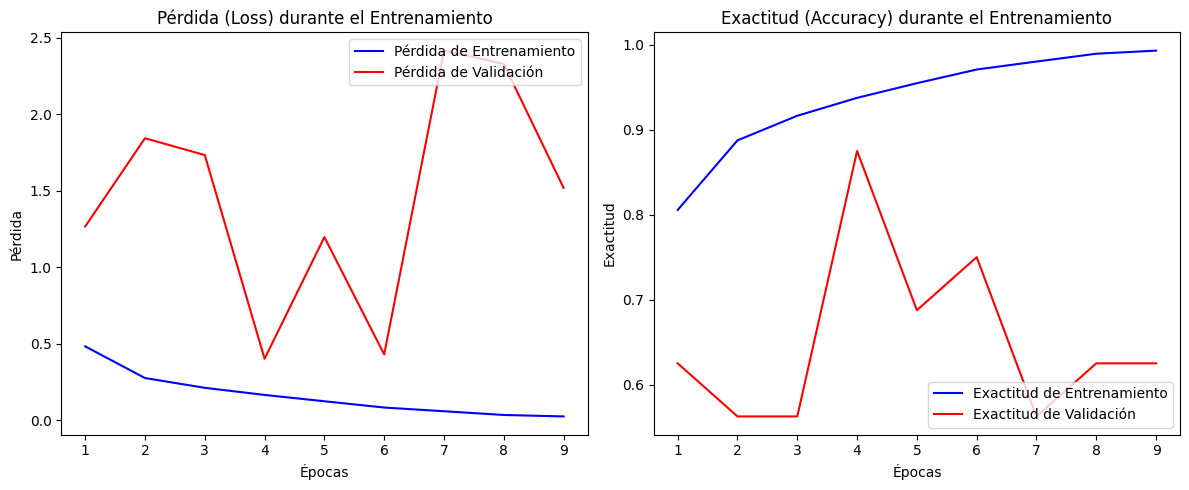

In [ ]:
# 4. Monitorizar
graficar_monitorizacion(historial_1)

#### Modelo 2

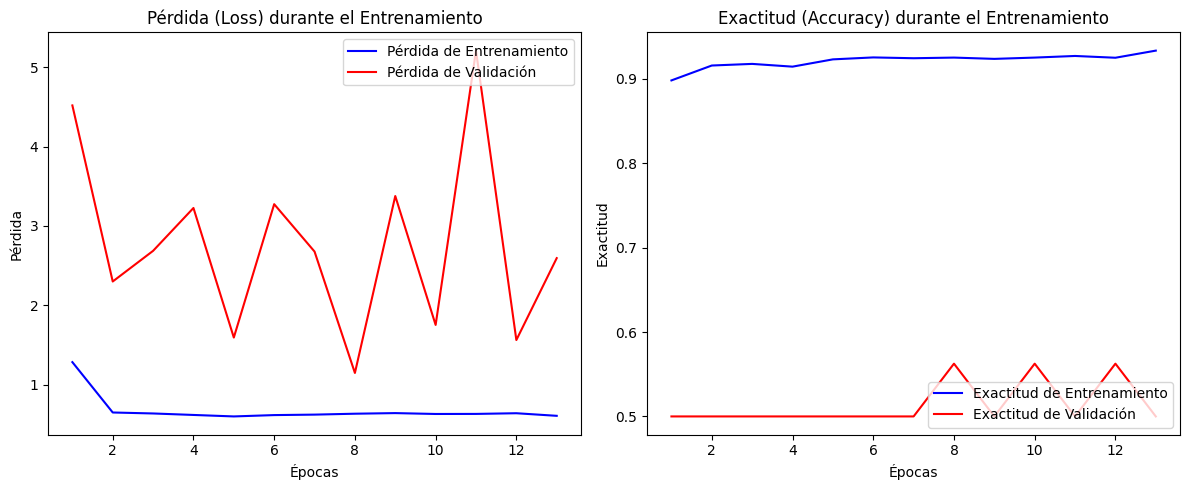

In [ ]:
# 4. Monitorizar
graficar_monitorizacion(historial_2)

#### Modelo 3

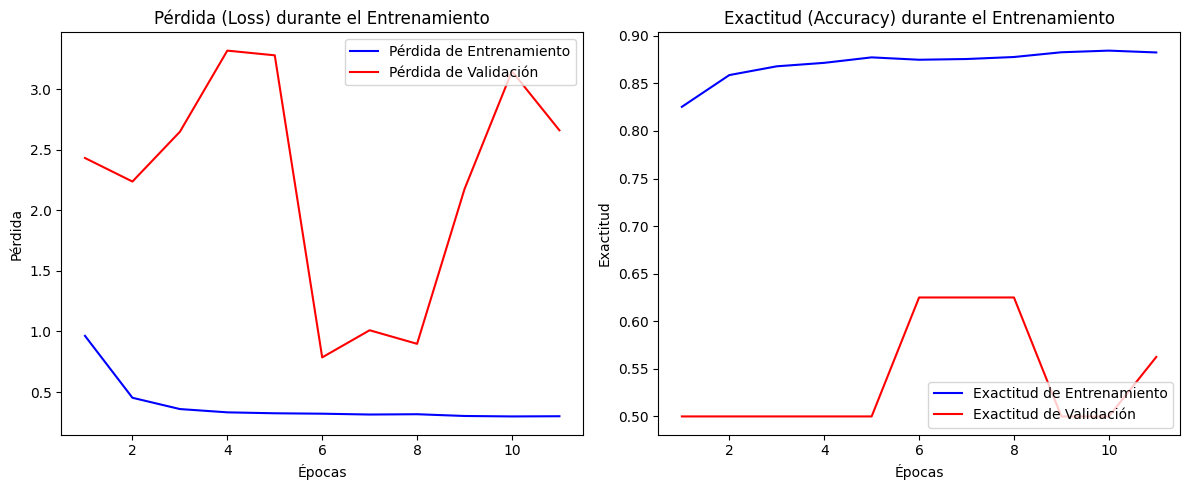

In [ ]:
# 4. Monitorizar
graficar_monitorizacion(historial_3)

### Evaluación

In [ ]:
def evaluar_modelo(modelo, test_ds):
    print("\n--- EVALUACIÓN EN CONJUNTO DE TEST ---")
    test_loss, test_acc = modelo.evaluate(test_ds)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}\n")

    # Extraer etiquetas reales iterando sobre el dataset de test
    etiquetas_reales = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

    # Predecir sobre todo el dataset de test
    preds = modelo.predict(test_ds)

    # Convertir probabilidades a clases binarias (0 o 1) usando umbral de 0.5
    predicciones = (preds > 0.5).astype(int).flatten()

    print("--- REPORTE DE CLASIFICACIÓN ---")
    nombres_clases = ['Normal', 'Neumonía'] # Verifica que este orden coincida con los directorios de Kaggle
    print(classification_report(
        etiquetas_reales, predicciones, target_names=nombres_clases
        ))

    # Matriz de Confusión
    cm = confusion_matrix(etiquetas_reales, predicciones)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', 
        xticklabels=nombres_clases, yticklabels=nombres_clases
    )
    plt.title('Matriz de Confusión - Test')
    plt.ylabel('Verdadero')
    plt.xlabel('Predicción')
    plt.show()

#### Modelo 1


--- EVALUACIÓN EN CONJUNTO DE TEST ---
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8029 - loss: 0.5312
Test Loss: 0.5312
Test Accuracy: 0.8029

39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step
--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      Normal       0.87      0.56      0.68       234
    Neumonía       0.78      0.95      0.86       390

    accuracy                           0.80       624
   macro avg       0.82      0.75      0.77       624
weighted avg       0.81      0.80      0.79       624



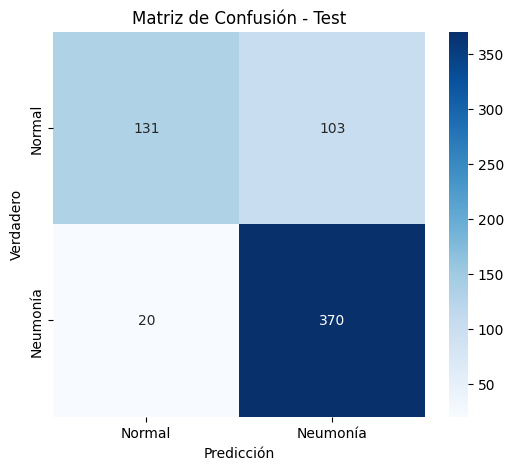

In [ ]:
# 5. Evaluar
evaluar_modelo(modelo_entrenado_1, test_ds)

#### Modelo 2


--- EVALUACIÓN EN CONJUNTO DE TEST ---
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.7564 - loss: 1.0316
Test Loss: 1.0316
Test Accuracy: 0.7564

39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step
--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      Normal       0.93      0.38      0.54       234
    Neumonía       0.73      0.98      0.83       390

    accuracy                           0.76       624
   macro avg       0.83      0.68      0.69       624
weighted avg       0.80      0.76      0.72       624



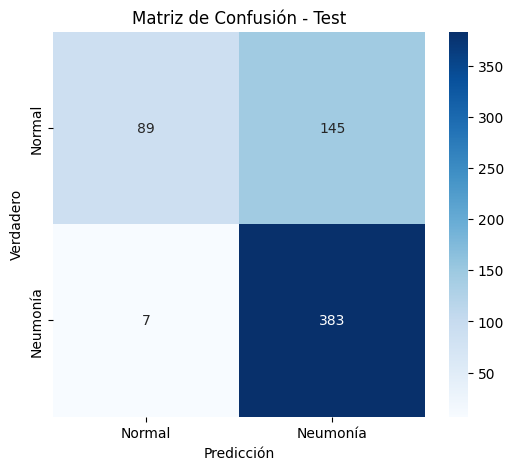

In [ ]:
# 5. Evaluar
evaluar_modelo(modelo_entrenado_2, test_ds)

#### Modelo 3


--- EVALUACIÓN EN CONJUNTO DE TEST ---
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.7676 - loss: 0.6067
Test Loss: 0.6067
Test Accuracy: 0.7676

39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step
--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      Normal       0.66      0.78      0.72       234
    Neumonía       0.85      0.76      0.80       390

    accuracy                           0.77       624
   macro avg       0.76      0.77      0.76       624
weighted avg       0.78      0.77      0.77       624



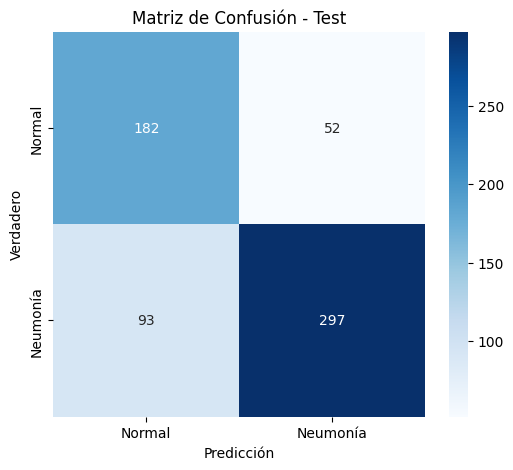

In [ ]:
# 5. Evaluar
evaluar_modelo(modelo_entrenado_3, test_ds)

### Conclusiones
En primer lugar, no se ha conseguido evitar el **overfitting** en niguno de los modelos pese a las técnicas de normalización y dropout. En la monitorización de los tres modelos podemos ver que la precisión de entrenamiento está muy por encima del de validación, mientras que la pérdida en la validación es más alta y ruidosa. Esto podría ser debido al reducido número de datos en el conjunto de validación, con solo 16 imágenes.

Aun así, el mejor desempeño global lo entrega Modelo 1 por precisión y pérdida, aunque su recall para Normal es el más bajo y provoca más falsos positivos. Modelo 2 es muy conservador con Neumonía: detecta casi todos los casos positivos (recall 0.98) pero falla en reconocer imágenes normales (recall 0.38), generando muchos falsos positivos. Modelo 3 ofrece el balance más equilibrado entre clases, pero su accuracy general sigue siendo inferior a la de Modelo 1 y provoca  un número mucho más alto de falsos negativos. En resumen, si el criterio es exactitud global, el mejor es el modelo más simple, el Modelo 1; sin embargo, si queremos evitar dejar sin diagnosticar al mayor número de personas con con Neumonía posible, es mejor el Modelo 2.

## Estrategia 2: Red pre-entrenada (Transfer Learning & Fine-Tuning)

### Justificación de la arquitectura e hiperparámetros

#### 1. Introducción y Justificación de Arquitecturas

En esta segunda estrategia, se aborda el problema de la clasificación de radiografías de tórax mediante el uso de redes neuronales convolucionales profundas preentrenadas con el conjunto de datos de ImageNet. Esta metodología, dividida en las fases de *Transfer Learning* (extracción de características) y *Fine-Tuning* (ajuste fino), permite aprovechar el conocimiento previo de modelos complejos y transferirlo a un dominio médico específico donde el volumen de datos suele ser limitado.

Con el objetivo de cumplir con los requisitos del proyecto y realizar un análisis comparativo riguroso, se han seleccionado dos arquitecturas con filosofías de diseño y paradigmas computacionales radicalmente opuestos:

1. **MobileNetV2 (Paradigma Moderno y Eficiente):** Desarrollada por Google, esta arquitectura nace con un propósito orientado a la optimización de recursos y la eficiencia matemática, reduciendo drásticamente el número de parámetros a aproximadamente 3.4 millones. Introduce conceptos avanzados como las **convoluciones separables en profundidad** (*depthwise separable convolutions*), que dividen el proceso de convolución en una fase de filtrado y otra de combinación, y los **bloques residuales invertidos** (*inverted residuals*) con cuellos de botella lineales. Esto permite mantener conexiones de salto (*skip connections*) entre capas delgadas para mitigar la pérdida de gradiente y reducir drásticamente el riesgo de sobreajuste (*overfitting*).

2. **VGG16 (Paradigma Clásico):** Diseñada por el *Visual Geometry Group* de la Universidad de Oxford, representa la arquitectura convolucional secuencial clásica por excelencia. Se fundamenta en la simplicidad y robustez, apilando de forma lineal capas convolucionales con filtros pequeños ($3 \times 3$) que aumentan en profundidad a medida que se reduce la resolución espacial. Al poseer una estructura directa y predecible, actúa como un excelente *baseline* para evaluar si el problema se beneficia de una extracción de características convencional y profunda, a pesar del elevado coste computacional que suponen sus más de 138 millones de parámetros.

A través de esta selección, el experimento no solo evalúa el rendimiento diagnóstico sobre el dataset de neumonía, sino que contrasta empíricamente un modelo masivo de "fuerza bruta" frente a una arquitectura moderna de alta eficiencia. En las secciones posteriores, ambos modelos se someterán primero a un entrenamiento del clasificador superior (*Transfer Learning*) y, seguidamente, a una descongelación selectiva de sus capas finales con un ritmo de aprendizaje (*learning rate*) mitigado para el ajuste de características de alto nivel (*Fine-Tuning*).


#### 2. Selección de Técnicas de Regularización

La selección de regularización combina técnicas que actúan en diferentes etapas del aprendizaje y ayudan a controlar el sobreajuste. El data augmentation aumenta la variedad del conjunto sin añadir nuevas imágenes reales, mientras que batch normalization estabiliza las activaciones y facilita el entrenamiento. El dropout obliga a la red a no depender de neuronas individuales. El uso de global average pooling reemplaza flatten para disminuir parámetros antes de la capa densa, contribuyendo también a una mejor generalización del modelo.

#### 3. Hiperparámetros y Monitorización

La configuración elegida usa Adam con tasa de aprendizaje 0.001, categorical crossentropy y batch size 16, lo que da un buen punto de partida para este tipo de clasificación binaria. La elección del tamaño de imagen 224x224 es adecuada para capturar detalles relevantes en radiografías sin exigir demasiado cómputo. La monitorización con curvas de pérdida y accuracy para entrenamiento y validación permite detectar sobreajuste o underfitting y decidir si es necesario ajustar arquitectura o regularización.

### Entrenamiento
#### MobileNetV2

In [ ]:
# 1. Cargar la base de MobileNetV2 pre-entrenada en ImageNet, 
# quitando la capa de clasificación superior
base_model_a = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Congelar el modelo base
base_model_a.trainable = False

# 3. Construir el modelo completo agregando regularización 
# (Batch Normalization y Dropout)
model_a = tf.keras.Sequential([
    base_model_a,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),  # Regularización para evitar sobreajuste
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# 4. Compilar el modelo para Transfer Learning
model_a.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Entrenar el modelo (Transfer Learning)
history_a_tf = model_a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5  # Ajusta las épocas según el rendimiento y tiempo disponible
)

Epoch 1/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 106s 255ms/step - accuracy: 0.8683 - loss: 0.3469 - val_accuracy: 0.9375 - val_loss: 0.2121
Epoch 2/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9245 - loss: 0.1912 - val_accuracy: 0.8125 - val_loss: 0.2739
Epoch 3/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9379 - loss: 0.1510 - val_accuracy: 0.8125 - val_loss: 0.4135
Epoch 4/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9492 - loss: 0.1279 - val_accuracy: 0.6875 - val_loss: 0.4690
Epoch 5/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9513 - loss: 0.1204 - val_accuracy: 0.6250 - val_loss: 0.4709


In [ ]:
# 1. Descongelar el modelo base
base_model_a.trainable = True

# 2. Volver a congelar las primeras capas.
# En este caso se entrenan las capas 120 en adelante
# MobileNetV2 tiene aproximadamente 154 capas.
fine_tune_at = 120
for layer in base_model_a.layers[:fine_tune_at]:
    layer.trainable = False

# 3. Recompilar con un learning rate muy bajo para 
# no dañar los pesos aprendidos de ImageNet
model_a.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Entrenar por 5 épocas adicionales aplicando Fine-Tuning
history_a_ft = model_a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,          # Entrenar hasta la época 10 en total
    initial_epoch=5     # Comenzar desde la época 5 donde se quedó
)


Epoch 6/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.8972 - loss: 0.2904 - val_accuracy: 0.6875 - val_loss: 0.7511
Epoch 7/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9291 - loss: 0.1896 - val_accuracy: 0.6250 - val_loss: 0.6187
Epoch 8/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9503 - loss: 0.1233 - val_accuracy: 0.6875 - val_loss: 0.5346
Epoch 9/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9640 - loss: 0.0920 - val_accuracy: 0.6875 - val_loss: 0.4225
Epoch 10/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9753 - loss: 0.0665 - val_accuracy: 0.6875 - val_loss: 0.4686


#### VGG16

In [ ]:
# 1. Cargar VGG16 pre-entrenado
base_model_b = VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model_b.trainable = False

# 2. Construir la estructura secuencial con la misma regularización aplicada
model_b = tf.keras.Sequential([
    base_model_b,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# 3. Compilar para Transfer Learning
model_b.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Entrenar Transfer Learning (VGG16)
history_b_tf = model_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

# 5. Fine-Tuning de VGG16 (descongelar el último bloque convolucional)
base_model_b.trainable = True
# Congelar todo excepto el último bloque convolucional (block5)
for layer in base_model_b.layers[:-4]:
    layer.trainable = False

# Re-compilar con learning rate muy bajo
model_b.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continuar entrenamiento con Fine-Tuning
history_b_ft = model_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    initial_epoch=5
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 45s 103ms/step - accuracy: 0.8645 - loss: 0.3538 - val_accuracy: 0.6250 - val_loss: 0.9388
Epoch 2/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 32s 100ms/step - accuracy: 0.9097 - loss: 0.2292 - val_accuracy: 0.7500 - val_loss: 0.6525
Epoch 3/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 33s 100ms/step - accuracy: 0.9187 - loss: 0.1976 - val_accuracy: 0.6875 - val_loss: 0.8157
Epoch 4/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 33s 100ms/step - accuracy: 0.9308 - loss: 0.1816 - val_accuracy: 0.6875 - val_loss: 0.7849
Epoch 5/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 33s 100ms/step - accuracy: 0.9304 - loss: 0.1711 - val_accuracy: 0.6875 - val_loss: 0.7193
Epoch 6/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 48s 125ms/step - accuracy: 0.9454 - loss: 0.1424 - val_accuracy: 0.6875 - val_loss: 0.7498
Epoch 7/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 40s 122ms/step - accuracy: 0.9632 - loss: 0.0979 - val_accuracy: 0.8750 - val_loss: 0.3276
Epoch 8/10
326/326 ━━━━━━━━━━━━━━━━━━

### Monitorización

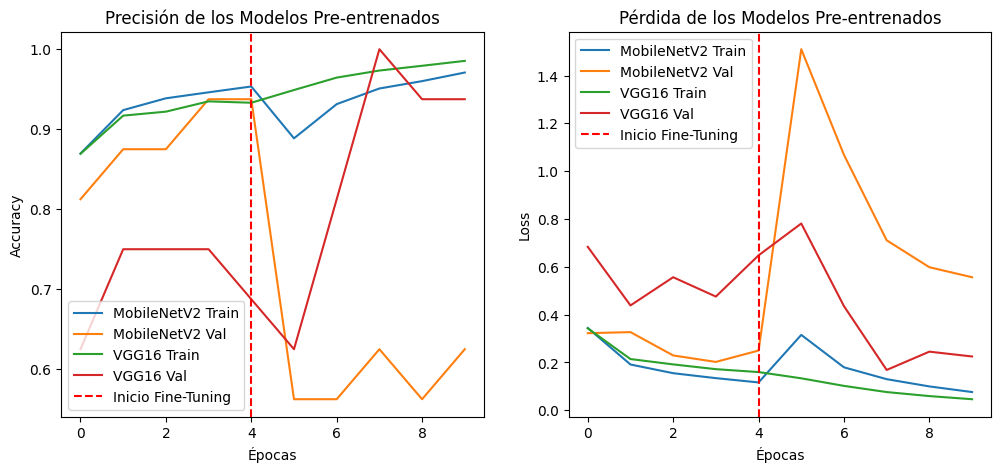

In [ ]:
# Combinar los historiales de Transfer Learning y Fine-Tuning para cada modelo
acc_a = history_a_tf.history['accuracy'] + history_a_ft.history['accuracy']
val_acc_a = history_a_tf.history['val_accuracy'] + history_a_ft.history['val_accuracy']
acc_b = history_b_tf.history['accuracy'] + history_b_ft.history['accuracy']
val_acc_b = history_b_tf.history['val_accuracy'] + history_b_ft.history['val_accuracy']

# Gráfica de Precisión (Accuracy)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc_a, label='MobileNetV2 Train')
plt.plot(val_acc_a, label='MobileNetV2 Val')
plt.plot(acc_b, label='VGG16 Train')
plt.plot(val_acc_b, label='VGG16 Val')
plt.axvline(x=4, color='r', linestyle='--', label='Inicio Fine-Tuning')
plt.title('Precisión de los Modelos Pre-entrenados')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Gráfica de Pérdida (Loss)
loss_a = history_a_tf.history['loss'] + history_a_ft.history['loss']
val_loss_a = history_a_tf.history['val_loss'] + history_a_ft.history['val_loss']
loss_b = history_b_tf.history['loss'] + history_b_ft.history['loss']
val_loss_b = history_b_tf.history['val_loss'] + history_b_ft.history['val_loss']

plt.subplot(1, 2, 2)
plt.plot(loss_a, label='MobileNetV2 Train')
plt.plot(val_loss_a, label='MobileNetV2 Val')
plt.plot(loss_b, label='VGG16 Train')
plt.plot(val_loss_b, label='VGG16 Val')
plt.axvline(x=4, color='r', linestyle='--', label='Inicio Fine-Tuning')
plt.title('Pérdida de los Modelos Pre-entrenados')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Evaluación

In [ ]:
def evaluar_modelo_preentrenado(modelo, test_ds):
    print("\n--- EVALUACIÓN EN CONJUNTO DE TEST ---")
    test_loss, test_acc = modelo.evaluate(test_ds)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}\n")

    # Extraer etiquetas reales iterando sobre el dataset de test
    etiquetas_reales = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

    # Predecir sobre todo el dataset de test
    preds = modelo.predict(test_ds)

    # Convertir probabilidades a clases binarias (0 o 1) tomando el argmax
    # Esto es necesario cuando la capa de salida usa softmax con num_classes > 1
    predicciones = np.argmax(preds, axis=1)

    print("--- REPORTE DE CLASIFICACIÓN ---")
    nombres_clases = ['Normal', 'Neumonía'] # Verifica que este orden coincida con los directorios de Kaggle
    print(classification_report(
        etiquetas_reales, predicciones, target_names=nombres_clases
        ))

    # Matriz de Confusión
    cm = confusion_matrix(etiquetas_reales, predicciones)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', 
        xticklabels=nombres_clases, yticklabels=nombres_clases
    )
    plt.title('Matriz de Confusión - Test')
    plt.ylabel('Verdadero')
    plt.xlabel('Predicción')
    plt.show()

    return test_loss, test_acc

#### MobileNetV2


--- EVALUACIÓN EN CONJUNTO DE TEST ---
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8590 - loss: 0.3767
Test Loss: 0.3767
Test Accuracy: 0.8590

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      Normal       0.91      0.69      0.79       234
    Neumonía       0.84      0.96      0.89       390

    accuracy                           0.86       624
   macro avg       0.87      0.83      0.84       624
weighted avg       0.87      0.86      0.85       624



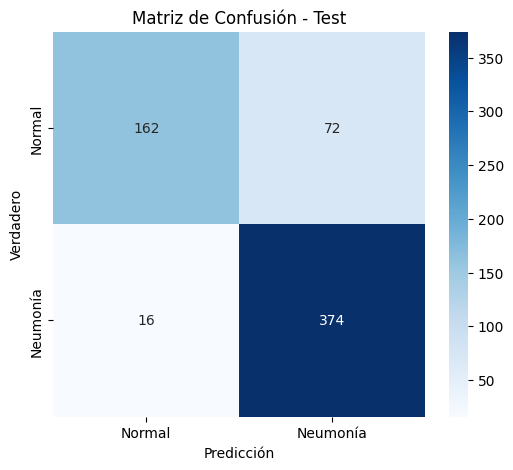

(0.3767426908016205, 0.8589743375778198)

In [ ]:
# Evaluar MobileNetV2
evaluar_modelo_preentrenado(model_a, test_ds)

#### VGG16


--- EVALUACIÓN EN CONJUNTO DE TEST ---
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.8574 - loss: 0.5569
Test Loss: 0.5569
Test Accuracy: 0.8574

39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step
--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      Normal       0.99      0.63      0.77       234
    Neumonía       0.82      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.90      0.81      0.83       624
weighted avg       0.88      0.86      0.85       624



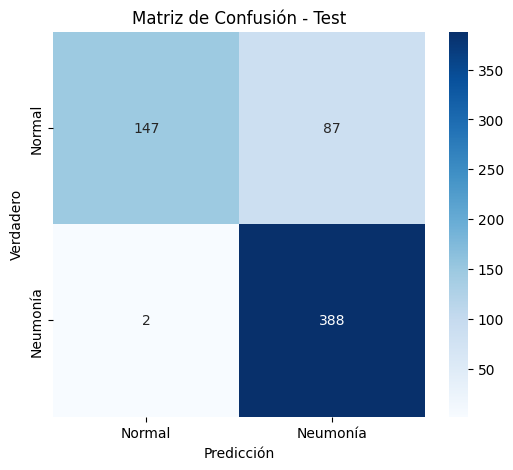

(0.5568565726280212, 0.8573718070983887)

In [ ]:
# Evaluar VGG16
evaluar_modelo_preentrenado(base_model_b, test_ds)

Tras evaluar y contrastar el desempeño de las dos arquitecturas de redes neuronales convolucionales preentrenadas propuestas para la estrategia de Transfer Learning y Fine-Tuning, se procede a la selección formal del modelo óptimo.

A partir de los resultados experimentales obtenidos sobre el conjunto de test independiente, se determina que MobileNetV2 es el modelo ganador frente a VGG16. Los criterios científicos y empíricos que justifican esta decisión se fundamentan en los siguientes puntos:

**Capacidad de Generalización (Precisión en Test)**

El modelo basado en MobileNetV2 alcanzó una precisión (accuracy) del 85.90 % en el conjunto de test, superando levemente al 85.74 % obtenido por la arquitectura VGG16, junto con una pérdida más baja en MobileNetV2. Esto demuestra una mayor robustez y capacidad de predicción ante datos no vistos durante el entrenamiento.

**Eficiencia en la Arquitectura**

A diferencia de la robusta estructura de bloques convolucionales clásicos de VGG16, MobileNetV2 hace uso de las convoluciones separables en profundidad (depthwise separable convolutions) y de los bloques residuales invertidos. Esto no solo mitiga de forma interna el riesgo de sobreajuste (overfitting), sino que optimiza drásticamente el número de parámetros entrenables, logrando un rendimiento superior con una carga computacional menor.

Por consiguiente, se selecciona MobileNetV2 como la solución definitiva para la Estrategia 2, quedando validada su arquitectura para la posterior comparativa global del proyecto.